# Plotting Training and Validation Loss

This notebook loads a saved model checkpoint (`.pth` file) and plots the training and validation loss curves over the epochs by calling a reusable plotting function from the `mhd_surrogate_core` package.

### 1. Setup and Imports

First, we import the necessary libraries and our new plotting function.

In [3]:
from pathlib import Path

# Make sure your packages are installed in editable mode
from mhd_surrogate_core.plot import plot_loss_curves

### 2. Specify Checkpoint Path and Plot

**Action Required:** Change the `checkpoint_path` variable below to point to the specific model checkpoint you want to analyze. This path should be relative to the notebook's location in the `notebooks/` directory.

2025-07-02 14:58:57,316 - INFO - Loading checkpoint from ../experiments/study_1_param_sweep/output/best_model.pth...


2025-07-02 14:58:57,624 - INFO - Found 4 epochs of training history.


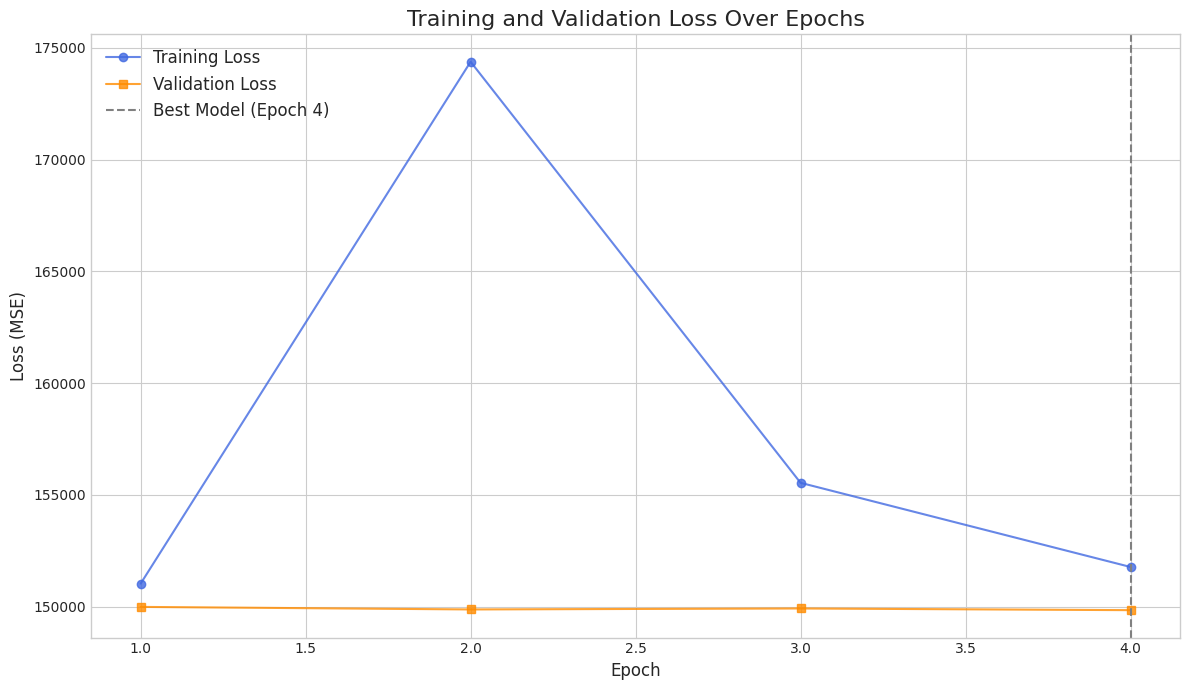

In [4]:
# Example path - update this to your specific run's output
checkpoint_path = Path("../experiments/study_1_param_sweep/output/best_model.pth")

# Call the plotting function
if checkpoint_path.exists():
    plot_loss_curves(checkpoint_path)
else:
    print(f"ERROR: Checkpoint file not found at {checkpoint_path}")
    print("Please update the 'checkpoint_path' variable.")

### Analysis

This plot is a key diagnostic tool:

- **Training Loss (Blue):** Should consistently decrease. If it's flat, the model may not be learning (e.g., learning rate is too low). If it's noisy, the learning rate might be too high.
- **Validation Loss (Orange):** This is the most important curve. It shows how well the model generalizes to unseen data. We are looking for the point where this curve is at its minimum (indicated by the dashed line). 
- **Overfitting:** If the training loss continues to decrease while the validation loss starts to increase, the model is overfitting. Our early stopping mechanism is designed to prevent this by stopping the training when the validation loss no longer improves.